<a href="https://colab.research.google.com/github/Sakhiur2022/Signal/blob/main/notebooks/04_modeling/02_ensembling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPR-03 — Model Training + Ensembling

**Ticket:** SPR-03
**Owner:** Sakhiur
**Depends on:** SPR-02 (resampled train set)
**Folder:** `notebooks/04_modeling/02_ensembling.ipynb`
**Output:** trained models saved to `models/{decision_tree,logistic_regression,random_forest,xgboost}/`, metrics logged to `results/tables/`

**Inspiration:** `SOTA_Paper_8.ipynb` cells 37-48 (hyperparameter search + VotingClassifier hard/soft voting), `cross-validation.ipynb` cells 37/40 (Stratified K-Fold evaluation loop). Adapted for multi-class `income_class` and depth-capped models to avoid the Colab stall documented earlier in the project.

## 1. Load resampled train set from SPR-02

In [1]:
!wget https://huggingface.co/datasets/Sakhiur/signal/resolve/main/X_train_resampled_Sakhiur.csv

--2026-08-25 17:36:28--  https://huggingface.co/datasets/Sakhiur/signal/resolve/main/X_train_resampled_Sakhiur.csv
Resolving huggingface.co (huggingface.co)... 3.170.185.14, 3.170.185.33, 3.170.185.35, ...
Connecting to huggingface.co (huggingface.co)|3.170.185.14|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/6a7c7183f2c81824bdfb6fa9/9f6172a1773ccf26810ab1921082ea2b55dd1e0849d93107fe3e14ac836e8fd0?X-Xet-Cas-Uid=public&response-content-type=text%2Fcsv&user_id=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27X_train_resampled_Sakhiur.csv%3B+filename%3D%22X_train_resampled_Sakhiur.csv%22%3B&Expires=1787682988&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNmE3YzcxODNmMmM4MTgyNGJkZmI2ZmE5LzlmNjE3MmExNzczY2NmMjY4MTBhYjE5MjEwODJlYTJiNTVkZDFlMDg0OWQ5MzEwN2ZlM2UxNGFjODM2ZThmZDBcXD9YLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LXR5cGU9KiZ1c2VyX2lkPXB1Ymx

In [2]:
!wget https://huggingface.co/datasets/Sakhiur/signal/resolve/main/X_test_Sakhiur.csv

--2026-08-25 17:36:34--  https://huggingface.co/datasets/Sakhiur/signal/resolve/main/X_test_Sakhiur.csv
Resolving huggingface.co (huggingface.co)... 3.170.185.14, 3.170.185.33, 3.170.185.25, ...
Connecting to huggingface.co (huggingface.co)|3.170.185.14|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: /api/resolve-cache/datasets/Sakhiur/signal/d35627bf94d1a8ad170c5553b07812318821ee95/X_test_Sakhiur.csv?%2Fdatasets%2FSakhiur%2Fsignal%2Fresolve%2Fmain%2FX_test_Sakhiur.csv=&etag=%2249ac492745f5c946abd59d29947ad5baa2a6d39d%22 [following]
--2026-08-25 17:36:34--  https://huggingface.co/api/resolve-cache/datasets/Sakhiur/signal/d35627bf94d1a8ad170c5553b07812318821ee95/X_test_Sakhiur.csv?%2Fdatasets%2FSakhiur%2Fsignal%2Fresolve%2Fmain%2FX_test_Sakhiur.csv=&etag=%2249ac492745f5c946abd59d29947ad5baa2a6d39d%22
Reusing existing connection to huggingface.co:443.
HTTP request sent, awaiting response... 200 OK
Length: 10184720 (9.7M) [text/plain]
Saving to:

In [4]:
!wget https://huggingface.co/datasets/Sakhiur/signal/resolve/main/y_train_resampled_Sakhiur.csv

--2026-08-25 17:36:42--  https://huggingface.co/datasets/Sakhiur/signal/resolve/main/y_train_resampled_Sakhiur.csv
Resolving huggingface.co (huggingface.co)... 3.170.185.14, 3.170.185.33, 3.170.185.25, ...
Connecting to huggingface.co (huggingface.co)|3.170.185.14|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: /api/resolve-cache/datasets/Sakhiur/signal/d35627bf94d1a8ad170c5553b07812318821ee95/y_train_resampled_Sakhiur.csv?%2Fdatasets%2FSakhiur%2Fsignal%2Fresolve%2Fmain%2Fy_train_resampled_Sakhiur.csv=&etag=%22d1dadfe2ca86451459223e55ad3fb4a057c0f083%22 [following]
--2026-08-25 17:36:42--  https://huggingface.co/api/resolve-cache/datasets/Sakhiur/signal/d35627bf94d1a8ad170c5553b07812318821ee95/y_train_resampled_Sakhiur.csv?%2Fdatasets%2FSakhiur%2Fsignal%2Fresolve%2Fmain%2Fy_train_resampled_Sakhiur.csv=&etag=%22d1dadfe2ca86451459223e55ad3fb4a057c0f083%22
Reusing existing connection to huggingface.co:443.
HTTP request sent, awaiting response...

In [3]:
!wget https://huggingface.co/datasets/Sakhiur/signal/resolve/main/y_test_Sakhiur.csv

--2026-08-25 17:36:37--  https://huggingface.co/datasets/Sakhiur/signal/resolve/main/y_test_Sakhiur.csv
Resolving huggingface.co (huggingface.co)... 3.170.185.14, 3.170.185.33, 3.170.185.25, ...
Connecting to huggingface.co (huggingface.co)|3.170.185.14|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: /api/resolve-cache/datasets/Sakhiur/signal/d35627bf94d1a8ad170c5553b07812318821ee95/y_test_Sakhiur.csv?%2Fdatasets%2FSakhiur%2Fsignal%2Fresolve%2Fmain%2Fy_test_Sakhiur.csv=&etag=%2265b12cabc0360608ebbdad6a81d0164f0522455e%22 [following]
--2026-08-25 17:36:37--  https://huggingface.co/api/resolve-cache/datasets/Sakhiur/signal/d35627bf94d1a8ad170c5553b07812318821ee95/y_test_Sakhiur.csv?%2Fdatasets%2FSakhiur%2Fsignal%2Fresolve%2Fmain%2Fy_test_Sakhiur.csv=&etag=%2265b12cabc0360608ebbdad6a81d0164f0522455e%22
Reusing existing connection to huggingface.co:443.
HTTP request sent, awaiting response... 200 OK
Length: 1199517 (1.1M) [text/plain]
Saving to: 

In [12]:
import pandas as pd
import numpy as np
import random
import joblib
import os

np.random.seed(42)
random.seed(42)

X_train = pd.read_csv('X_train_resampled_Sakhiur.csv')
y_train = pd.read_csv('y_train_resampled_Sakhiur.csv').iloc[:, 0]
X_test = pd.read_csv('X_test_Sakhiur.csv')
y_test = pd.read_csv('y_test_Sakhiur.csv').iloc[:, 0]

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (1049480, 25) Test: (150325, 25)


In [6]:
!pip install catboost -q


## 1b. Encode target labels
XGBoost requires integer class labels (0,1,2,...), not strings. This encodes `y_train`/`y_test` once here, and every downstream cell decodes predictions back to real class names before printing or plotting.

In [11]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

print('Class mapping:')
for i, label in enumerate(label_encoder.classes_):
    print(f'  {i} -> {label}')

Class mapping:
  0 -> Lower
  1 -> Middle
  2 -> No_income
  3 -> Upper


## 2. Hyperparameter search space
Same structure as `SOTA_Paper_8.ipynb` cell 39, trimmed to the four models your project actually uses (decision tree, RF, XGBoost, logistic regression) and depth-capped to stay inside Colab free-tier limits, per the compute constraint already flagged for this project.

In [8]:
param_distributions = {
    'DecisionTreeClassifier': {
        'max_depth': [5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'RandomForestClassifier': {
        'n_estimators': [100, 150, 200],
        'max_depth': [10],  # capped per project compute constraint, do not widen
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'XGBClassifier': {
        'n_estimators': [100, 150, 200],
        'max_depth': [6, 8, 10],
        'learning_rate': [0.01, 0.05, 0.1]
    },
    'LogisticRegression': {
        'C': [0.01, 0.1, 1.0, 10.0],
        'max_iter': [1000]
    },
    'CatBoostClassifier': {
        'iterations': [200, 400, 600],
        'depth': [6, 8, 10],
        'learning_rate': [0.01, 0.05, 0.1],
        'l2_leaf_reg': [3, 5, 7]
    }
}

## 3. Randomized search per model

## 3b. Manual resume: paste known best params to skip search
If Colab disconnects mid-search, or you already found good params in a previous run, paste them into `KNOWN_BEST_PARAMS` below. Any model listed here skips `RandomizedSearchCV` entirely and is just fit directly. Any model NOT listed here still goes through the normal search in the next cell.

Leave a model's entry out (or set the whole dict empty) to search everything from scratch.

In [9]:
# Fill in only the models you already have good params for. Leave others out entirely,
# they'll be searched normally below. Example after a DT+RF search already succeeded:
#
# KNOWN_BEST_PARAMS = {
#     'DecisionTreeClassifier': {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20},
#     'RandomForestClassifier': {'n_estimators': 100, 'min_samples_split': 10,
#                                 'min_samples_leaf': 4, 'max_depth': 10},
# }

KNOWN_BEST_PARAMS = {
     'DecisionTreeClassifier': {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20},
     'RandomForestClassifier': {'n_estimators': 100, 'min_samples_split': 10,
                                 'min_samples_leaf': 4, 'max_depth': 10},
     'XGBClassifier': {'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.05},

    'LogisticRegression': {'max_iter': 1000, 'C': 10.0}

}

if KNOWN_BEST_PARAMS:
    print('Will skip search for:', list(KNOWN_BEST_PARAMS.keys()))
else:
    print('No manual params provided, everything below will be searched fresh.')

Will skip search for: ['DecisionTreeClassifier', 'RandomForestClassifier', 'XGBClassifier', 'LogisticRegression']


In [10]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

base_models = {
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=42),
    'RandomForestClassifier': RandomForestClassifier(random_state=42),
    'XGBClassifier': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'LogisticRegression': LogisticRegression(random_state=42),
    'CatBoostClassifier': CatBoostClassifier(random_seed=42,loss_function='MultiClass',verbose=0)

}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_params = {}
best_estimators = {}

model_classes = {
    'DecisionTreeClassifier': DecisionTreeClassifier,
    'RandomForestClassifier': RandomForestClassifier,
    'XGBClassifier': XGBClassifier,
    'LogisticRegression': LogisticRegression,
    'CatBoostClassifier': CatBoostClassifier
}
model_fixed_kwargs = {
    'DecisionTreeClassifier': {'random_state': 42},
    'RandomForestClassifier': {'random_state': 42},
    'XGBClassifier': {'random_state': 42, 'eval_metric': 'mlogloss'},
    'LogisticRegression': {'random_state': 42},
    'CatBoostClassifier': {'random_seed': 42, 'loss_function': 'MultiClass', 'verbose': 0}

}

for name, model in base_models.items():
    if name in KNOWN_BEST_PARAMS:
        print(f'Skipping search for {name}, using provided params...')
        params = KNOWN_BEST_PARAMS[name]
        fitted = model_classes[name](**params, **model_fixed_kwargs[name])
        fitted.fit(X_train, y_train_enc)
        best_params[name] = params
        best_estimators[name] = fitted
        print(f'  Used params: {params}')
        continue

    print(f'Searching {name}...')
    search = RandomizedSearchCV(
        model, param_distributions[name],
        n_iter=10, cv=cv, scoring='f1_macro',
        random_state=42, n_jobs=-1
    )
    search.fit(X_train, y_train_enc)
    best_params[name] = search.best_params_
    best_estimators[name] = search.best_estimator_
    print(f'  Best params: {search.best_params_}')
    print(f'  Best CV macro F1: {search.best_score_:.4f}')

Skipping search for DecisionTreeClassifier, using provided params...
  Used params: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20}
Skipping search for RandomForestClassifier, using provided params...
  Used params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}
Skipping search for XGBClassifier, using provided params...
  Used params: {'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.05}
Skipping search for LogisticRegression, using provided params...


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Used params: {'max_iter': 1000, 'C': 10.0}
Searching CatBoostClassifier...
  Best params: {'learning_rate': 0.05, 'l2_leaf_reg': 7, 'iterations': 400, 'depth': 10}
  Best CV macro F1: 0.7649


## 4. Evaluate each tuned model on the held-out test set

--- DecisionTreeClassifier ---
              precision    recall  f1-score   support

       Lower      0.597     0.686     0.638     47885
      Middle      0.596     0.609     0.603     35182
   No_income      0.950     0.834     0.889     65593
       Upper      0.162     0.179     0.170      1665

    accuracy                          0.727    150325
   macro avg      0.576     0.577     0.575    150325
weighted avg      0.746     0.727     0.734    150325



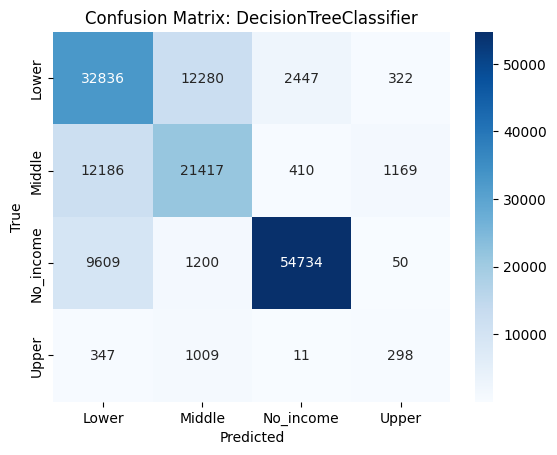

--- RandomForestClassifier ---
              precision    recall  f1-score   support

       Lower      0.598     0.701     0.646     47885
      Middle      0.583     0.571     0.577     35182
   No_income      0.992     0.797     0.884     65593
       Upper      0.101     0.427     0.163      1665

    accuracy                          0.710    150325
   macro avg      0.569     0.624     0.567    150325
weighted avg      0.761     0.710     0.728    150325



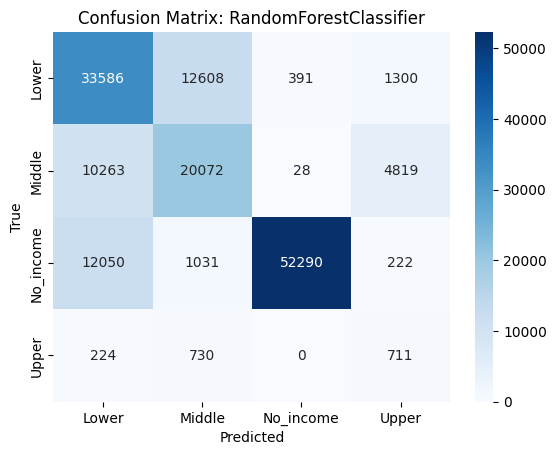

--- XGBClassifier ---
              precision    recall  f1-score   support

       Lower      0.616     0.720     0.664     47885
      Middle      0.625     0.649     0.637     35182
   No_income      0.970     0.831     0.895     65593
       Upper      0.198     0.186     0.191      1665

    accuracy                          0.746    150325
   macro avg      0.602     0.597     0.597    150325
weighted avg      0.768     0.746     0.753    150325



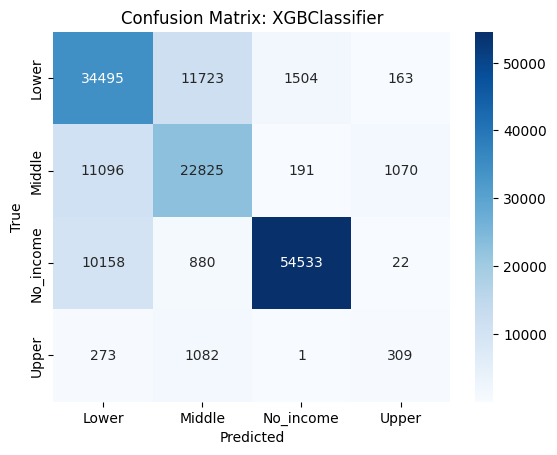

--- LogisticRegression ---
              precision    recall  f1-score   support

       Lower      0.594     0.684     0.636     47885
      Middle      0.569     0.542     0.555     35182
   No_income      0.966     0.817     0.885     65593
       Upper      0.114     0.421     0.180      1665

    accuracy                          0.706    150325
   macro avg      0.561     0.616     0.564    150325
weighted avg      0.745     0.706     0.721    150325



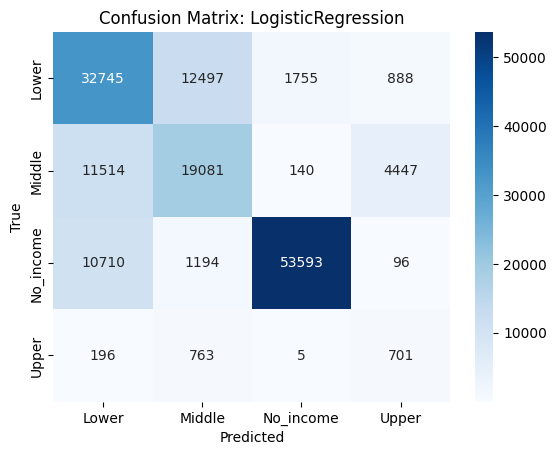

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


--- CatBoostClassifier ---
              precision    recall  f1-score   support

       Lower      0.617     0.716     0.663     47885
      Middle      0.623     0.649     0.636     35182
   No_income      0.969     0.833     0.896     65593
       Upper      0.197     0.206     0.201      1665

    accuracy                          0.746    150325
   macro avg      0.602     0.601     0.599    150325
weighted avg      0.768     0.746     0.753    150325



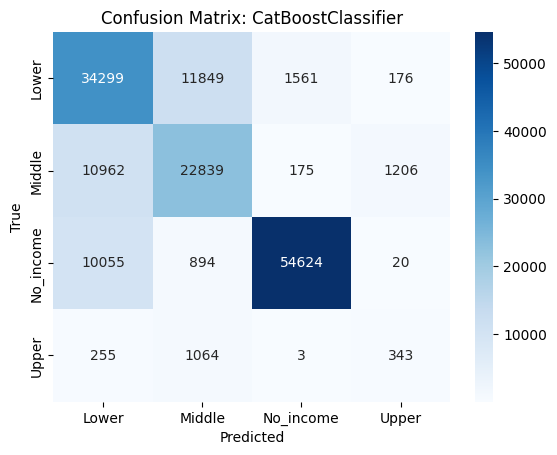

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

test_results = {}
for name, model in best_estimators.items():
    y_pred_enc = model.predict(X_test)
    y_pred = label_encoder.inverse_transform(y_pred_enc)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    test_results[name] = macro_f1
    print(f'--- {name} ---')
    print(classification_report(y_test, y_pred, digits=3))
    cm = confusion_matrix(y_test, y_pred, labels=label_encoder.classes_)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.show()

## 5. Ensembling: hard + soft voting
Adapted from `SOTA_Paper_8.ipynb` cell 44. `voting='soft'` requires every base estimator to support `predict_proba`, which all four models here do.

In [14]:
from sklearn.ensemble import VotingClassifier

voting_clf_hard = VotingClassifier(
    estimators=[(name, model) for name, model in best_estimators.items()],
    voting='hard'
)
voting_clf_soft = VotingClassifier(
    estimators=[(name, model) for name, model in best_estimators.items()],
    voting='soft'
)

print('Training hard voting ensemble...')
voting_clf_hard.fit(X_train, y_train_enc)
print('Training soft voting ensemble...')
voting_clf_soft.fit(X_train, y_train_enc)

Training hard voting ensemble...


KeyboardInterrupt: 

## 6. Evaluate ensembles

--- Hard Voting ---
              precision    recall  f1-score   support

       Lower      0.600     0.750     0.666     47885
      Middle      0.628     0.617     0.622     35182
   No_income      0.985     0.809     0.888     65593
       Upper      0.177     0.211     0.192      1665

    accuracy                          0.739    150325
   macro avg      0.597     0.597     0.592    150325
weighted avg      0.770     0.739     0.748    150325



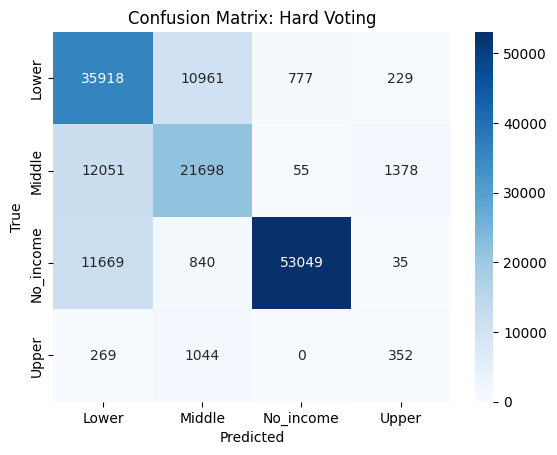

--- Soft Voting ---
              precision    recall  f1-score   support

       Lower      0.610     0.713     0.657     47885
      Middle      0.612     0.635     0.624     35182
   No_income      0.973     0.824     0.893     65593
       Upper      0.173     0.234     0.199      1665

    accuracy                          0.738    150325
   macro avg      0.592     0.602     0.593    150325
weighted avg      0.764     0.738     0.747    150325



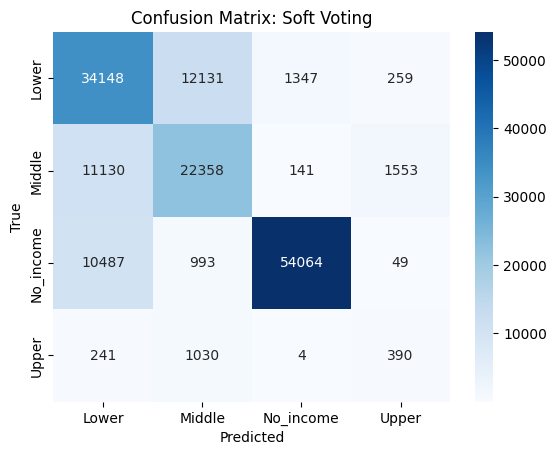


Final comparison (macro F1):
XGBClassifier: 0.5968
Soft Voting: 0.5932
Hard Voting: 0.5923
DecisionTreeClassifier: 0.5749
RandomForestClassifier: 0.5674
LogisticRegression: 0.5640


In [ ]:
for clf, label in zip([voting_clf_hard, voting_clf_soft], ['Hard Voting', 'Soft Voting']):
    y_pred_enc = clf.predict(X_test)
    y_pred = label_encoder.inverse_transform(y_pred_enc)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    test_results[label] = macro_f1
    print(f'--- {label} ---')
    print(classification_report(y_test, y_pred, digits=3))
    cm = confusion_matrix(y_test, y_pred, labels=label_encoder.classes_)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix: {label}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.show()

print('\nFinal comparison (macro F1):')
for name, score in sorted(test_results.items(), key=lambda x: -x[1]):
    print(f'{name}: {score:.4f}')

## 7. Save models and metrics
This is the handoff point for SPR-04 (figures) and SPR-05 (SHAP), both of which read these saved models read-only and must not retrain them.

In [15]:
os.makedirs('models/decision_tree', exist_ok=True)
os.makedirs('models/random_forest', exist_ok=True)
os.makedirs('models/xgboost', exist_ok=True)
os.makedirs('models/logistic_regression', exist_ok=True)
os.makedirs('results/tables', exist_ok=True)
os.makedirs('models/catboost', exist_ok=True)

joblib.dump(best_estimators['DecisionTreeClassifier'], 'models/decision_tree/model.joblib')
joblib.dump(best_estimators['RandomForestClassifier'], 'models/random_forest/model.joblib')
joblib.dump(best_estimators['XGBClassifier'], 'models/xgboost/model.joblib')
joblib.dump(best_estimators['LogisticRegression'], 'models/logistic_regression/model.joblib')
joblib.dump(best_estimators['CatBoostClassifier'], 'models/catboost/model.joblib')
#joblib.dump(voting_clf_soft, 'models/voting_ensemble_soft.joblib')
#joblib.dump(voting_clf_hard, 'models/voting_ensemble_hard.joblib')

results_df = pd.DataFrame(list(test_results.items()), columns=['model', 'macro_f1'])
results_df = results_df.sort_values('macro_f1', ascending=False)
results_df.to_csv('results/tables/model_comparison.csv', index=False)
print(results_df)
print('\nBest model for SPR-05 SHAP analysis:', results_df.iloc[0]['model'])

# Save the label encoder so SPR-04 / SPR-05 can decode predictions back to class names
joblib.dump(label_encoder, 'models/label_encoder.joblib')
print('Saved models/label_encoder.joblib')

                    model  macro_f1
4      CatBoostClassifier  0.598993
2           XGBClassifier  0.596848
0  DecisionTreeClassifier  0.574914
1  RandomForestClassifier  0.567391
3      LogisticRegression  0.563971

Best model for SPR-05 SHAP analysis: CatBoostClassifier
Saved models/label_encoder.joblib
